LabelEncoders sauvegardés  RF_model.py:50 - test.ipynb:65
LabelEncoders sauvegardés  RF_model.py:56 - test.ipynb:71
entrenement  RF_model.py:85 - test.ipynb:100
prediction  RF_model.py:89 - test.ipynb:104
[[167521    136]
 [  1442    817]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    167657
           1       0.86      0.36      0.51      2259

    accuracy                           0.99    169916
   macro avg       0.92      0.68      0.75    169916
weighted avg       0.99      0.99      0.99    169916



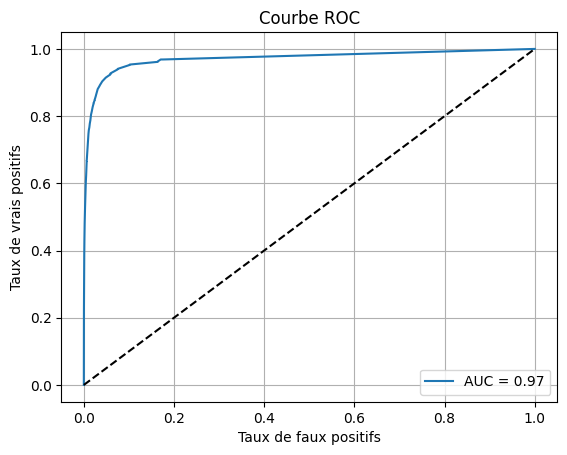

the model is serialized with succes  RF_model.py:120 - test.ipynb:135


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
)
import warnings

warnings.filterwarnings("ignore")
import pickle

# chargement des données
df = pd.read_csv("Datasets/Training_BOP.csv")


# Nettoyage des valeurs manquants et des valeurs spéciales
df = df.replace(-99, np.nan)
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# --- Encodage des variables catégorielles et sauvegarde des encoders ---
cat_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
    "went_on_backorder",
]

encoders = {}  # dictionnaire pour stocker chaque encoder
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # sauvegarder l'encoder

# Sauvegarder tous les encoders dans un fichier
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("LabelEncoders sauvegardés  RF_model.py:50 - test.ipynb:65")

# Sauvegarder tous les encoders dans un fichier
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("LabelEncoders sauvegardés  RF_model.py:56 - test.ipynb:71")


# 1. Séparer les classes
minority_df = df[df["went_on_backorder"] == 1]
majority_df = df[df["went_on_backorder"] == 0]

# 2. Downsampling léger de la classe majoritaire (réduction à 50%)
majority_downsampled = majority_df.sample(frac=0.5, random_state=42)

# 5. Concaténer tous les jeux de données
df_partial = pd.concat([minority_df, majority_downsampled], axis=0)

# 6. Séparer features / target
X = df_partial.drop(["sku", "went_on_backorder"], axis=1)
y = df_partial["went_on_backorder"]

X_bal, y_bal = X, y

# 7. Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# 8. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 9. Standardisation

print("entrenement  RF_model.py:85 - test.ipynb:100")
# 9. Entraînement
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
print("prediction  RF_model.py:89 - test.ipynb:104")
# 10. Prédictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# 11. Évaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 12. Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()




In [2]:
test=pd.read_csv("Datasets/Testing_BOP.csv")
test.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
1,3285131,9.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,Yes,No,No,No
2,3285358,17.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.92,0.95,0.0,No,No,No,Yes,No,No
3,3285517,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.78,0.75,0.0,No,No,Yes,Yes,No,No
4,3285608,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.54,0.71,0.0,No,No,No,Yes,No,No


In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. Charger le modèle et le scaler ---
with open("../Models/random_forest_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../Models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# --- 2. Charger les encoders ---
with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

# --- 3. Charger les données de test ---
test = pd.read_csv("Datasets/Testing_BOP.csv")

# --- 4. Nettoyage des valeurs manquantes ---
test = test.replace(-99, np.nan)
for col in test.columns:
    if test[col].dtype == "object":
        test[col] = test[col].fillna(test[col].mode()[0])
    else:
        test[col] = test[col].fillna(test[col].median())

# --- 5. Encoder les colonnes catégorielles (mêmes colonnes que pour l'entraînement, sauf target) ---
cat_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
]

for col in cat_cols:
    le = encoders[col]  # récupérer l'encoder entraîné
    test[col] = le.transform(test[col])

# --- 6. Sélectionner les features pour la prédiction ---
feature_columns = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "potential_issue",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
]

X_test_final = test[feature_columns]

# --- 7. Standardiser les données ---
X_test_scaled = scaler.transform(X_test_final)

# --- 8. Faire les prédictions ---
test["pred_went_on_backorder"] = model.predict(X_test_scaled)

# --- 9. Facultatif : probabilités si tu veux ---
test["prob_went_on_backorder"] = model.predict_proba(X_test_scaled)[:, 1]

# --- 10. Afficher ou sauvegarder ---
test[["sku", "pred_went_on_backorder", "prob_went_on_backorder"]].head()

# test.to_csv("Datasets/Testing_BOP_with_predictions.csv", index=False)

,sku,pred_went_on_backorder,prob_went_on_backorder
0,3285085,0,0.0
1,3285131,0,0.0
2,3285358,0,0.0
3,3285517,0,0.0
4,3285608,0,0.0


In [4]:
test["pred_went_on_backorder"].value_counts()

pred_went_on_backorder
0    241777
1       299
Name: count, dtype: int64

In [5]:
test[test["pred_went_on_backorder"]==1]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,pred_went_on_backorder,prob_went_on_backorder
859,3297699,1.0,0.0,0.0,238.0,338.0,463.0,34.0,118.0,247.0,...,0.00,5.0,0,0,1,0,0,No,1,0.79000
1352,3323488,0.0,2.0,0.0,16.0,16.0,16.0,9.0,21.0,34.0,...,0.96,0.0,0,0,0,1,0,Yes,1,0.60000
4468,3496116,4.0,8.0,0.0,251.0,373.0,500.0,65.0,133.0,320.0,...,0.91,0.0,0,0,0,1,0,No,1,0.56000
4993,3383741,0.0,8.0,0.0,25.0,40.0,55.0,10.0,27.0,45.0,...,0.57,0.0,0,0,0,1,0,Yes,1,0.58000
5002,3421527,0.0,4.0,0.0,24.0,35.0,46.0,22.0,27.0,46.0,...,0.86,0.0,0,0,0,1,0,Yes,1,0.66000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238869,3523696,0.0,4.0,0.0,12.0,20.0,36.0,4.0,10.0,18.0,...,0.89,0.0,0,0,0,1,0,No,1,0.51000
239108,3523948,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.96,0.0,0,0,0,1,0,No,1,0.77972
239246,3524088,0.0,2.0,0.0,40.0,60.0,80.0,2.0,17.0,35.0,...,0.89,0.0,0,0,0,1,0,Yes,1,0.52000
239871,3524729,0.0,2.0,0.0,6.0,12.0,16.0,3.0,9.0,16.0,...,0.87,0.0,0,0,0,1,0,No,1,0.56000


In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- 1. Charger le dataset test ---
test_df = pd.read_csv("Datasets/Testing_BOP.csv")

# Nettoyage identique à l'entraînement
test_df = test_df.replace(-99, np.nan)
for col in test_df.columns:
    if test_df[col].dtype == "object":
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])
    else:
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

# Encodage identique (⚠️ attention : ici il faudrait idéalement réutiliser les LabelEncoder de l'entraînement.
# Si tes colonnes sont les mêmes et prennent les mêmes valeurs, ça passera)
cat_cols = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
    "went_on_backorder",
]
for col in cat_cols:
    le = LabelEncoder()
    test_df[col] = le.fit_transform(test_df[col])

# --- 2. Séparer features et target ---
X_test = test_df.drop(columns=["went_on_backorder", "sku"])
y_test = test_df["went_on_backorder"]

# --- 3. Charger le scaler sauvegardé et transformer ---
scaler = joblib.load("scaler.pkl")
X_test_scaled = scaler.transform(X_test)

# --- 4. Reshape pour CNN ---
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# --- 5. Charger le modèle CNN sauvegardé ---
model = load_model("model_cnn.keras")

# --- 6. Prédictions ---
y_proba = model.predict(X_test_cnn).ravel()
y_pred = (y_proba > 0.5).astype(int)

# --- 7. Évaluation ---
print("Confusion Matrix: - test.ipynb:52")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report: - test.ipynb:55")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nTest ROCAUC: {roc_auc:.4f} - test.ipynb:59")

ModuleNotFoundError: No module named 'tensorflow'